In [1]:
from funcs import *
import pandas as pd
import cvxpy as cp
import numpy as np
from numpy.linalg import pinv
from scipy.sparse import lil_matrix
from scipy.stats import binom
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import tqdm
from tqdm import trange

# Bootstrapping, Model and the Quantile Universal Threshold

In this notebook, we will be performing a variety of statistical methods to ensure that there is a signal to be captured within the movement data alongside generating distributions of our $\lambda$ values using bootstrapping techniques. The Quantile Universal Threshold (QUT) will be calculated using a combination of the two techniques and will be described in further detail within the notebook.

For consistency and interpretability, all ball movements will directed towards one basket, which will be on the right side of all future visualizations.

We use a binomial linear inverse problem to model the binary response using a total variation regularization method to enforce smoothness and spacial coherence. The model is as follows:


\begin{aligned}
\min_{\mu \in \mathbb{R}^p}
- \log L\!\left(g^{-1}(X\mu);\, y\right)
+ \lambda \sum_{l=1}^{p} \sum_{l' \in \mathcal{N}_l} \lvert \mu_l - \mu_{l'} \rvert
\end{aligned}

Where $\mu$ is the propensity score acquired from a logit link function for a region in our map which is denoted with $\mu_l$ and $\mu_l'$ is the corresponding neighbours that belong to the set $\mathcal{N}_l$. In this scenario, the neighbours align to four directions: North, South, East and West of the cell $\mu$. $-logL$ is the negative log likelihood where $X$ is the time matrix for individual possessions, $y$ is the response vector (score/no score) and $\mu$ is the surface we are attempting to reconstruct. $\lambda$ is our regularization parameter that enforces smoothness between areas under the assumption that $\mu$ and it's neighbours $\mu_l'$ are close numerically. In short, we are attempting to solve for $\mu$ using an inverse linear method where:

\begin{aligned}
\ Y \sim Bernoulli(g^{-1}(X\mu))
\end{aligned}

In [2]:
df = pd.read_csv("Data/bootstrapped_analysis_ready.csv")

mask = df["period"] > 2
df.loc[mask, "x_bin"] = 20 - 1 - df.loc[mask, "x_bin"]
df.loc[mask, "y_bin"] = 10 - 1 - df.loc[mask, "y_bin"]

df['x_bin'] = np.clip(df['x_bin'], 0, 20 - 1)
df['y_bin'] = np.clip(df['y_bin'], 0, 10 - 1)

df

,Unnamed: 0,period,time,x,y,z,possession_start,possession_end,possession_number,scored,x_bin,y_bin
0,5478,1,519.52,88.59020,23.33939,7.01082,525.0,517.0,100000,1,18,4
1,5393,1,522.92,60.33963,47.03315,5.05533,525.0,517.0,100000,1,12,9
2,5156,1,524.40,56.15521,46.22760,4.01930,525.0,517.0,100000,1,11,9
3,5465,1,520.04,86.94073,22.81185,7.60527,525.0,517.0,100000,1,18,4
4,5522,1,517.76,91.09229,30.78871,4.90019,525.0,517.0,100000,1,19,6
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,25788,1,32.22,38.09371,25.18775,3.11391,33.0,15.0,100999,1,8,5
99996,26215,1,16.38,89.32768,26.19356,10.86343,33.0,15.0,100999,1,19,5
99997,25874,1,30.02,51.96869,25.74845,1.19712,33.0,15.0,100999,1,11,5
99998,25775,1,32.74,35.54421,26.63212,2.20840,33.0,15.0,100999,1,7,5


## First Bootstrap and QUT Calculation

The goal of the QUT is to generate values of our $\lambda$ that drive the response of our model to zero, essentially generating a constant signal across our generated threat map. Our alternate hypothesis is that there is a signal to be captured, so we must provide sufficient evidence that the signal is non-noisy or random data requires a sufficiently weaker $\lambda$ value to drive our threat map values to a constant signal. Because our original data set is small, we use bootstrapping to generate a distribution of $\lambda$ values under the null and the actual data.

The first bootstrapped data set was created in the `testing.ipynb` file where we randomly selected $1000$ possessions and $100$ positions from each posssession, both done with replacement. With this data set, we perform our QUT calculation by simulating a null response by applying logistic regression to our `X` matrix (movement data) with the `y` target vector (scored/no score). The model collapses our input matrix into a single vector to get a a single coefficient, `B0`, which will act as a baseline for our null response that assumes there is no signal to be captured within our data. We then use `B0` to generate probalities (`p`) of scoring under the null hypothesis. Too simplify the above statement, we can say that the null model depends on how many sectors a possession travels through, not which sectors. 

With `p`, we then solve a convex optimization problem to generate the max $\lambda$ values to drive the response to zero for both the null model and the actual model. The formulation of the problem is as follows:


\begin{aligned}
\min_{w \in \mathbb{R}^m} \quad & \| w \|_{\infty} \\
\text{s.t.} \quad & D^{\mathsf{T}} w = \nabla_h
\end{aligned}

where $w$ is our variable to optimize, $||w||_\infty$ is the infinity normal, $D^T$ is our total variation matrix that represents the difference between neighbouring edges, and $\Delta_h$ is our gradient of the predicted `p` subtracted from our actual `y` values.

We run this simulation $500$ times in the cells below.

In [3]:
X, y, D_TV = grid(df)

lambda_qut_val, lambda_max, lambdas_null = lambda_qut(X, y, D_TV, MC=500)

Simulating null responses...
Accepted 100 / 500 simulations
Accepted 200 / 500 simulations
Accepted 300 / 500 simulations
Accepted 400 / 500 simulations
Accepted 500 / 500 simulations
λ_qut (95th percentile null): 15.0582
λ_max (data): 32.4136


## Results

After running the simulations, we can see that there is a statistically significant difference between $\lambda_{max}$ and the 95th percentile of our null, or $\lambda_{QUT}$. Before we make any claims, we will enhance this and perform the same QUT methods on multiple bootstrapped datasets to get a distribution of $\lambda_{max}$ and $\lambda_{QUT}$ so we can compare them using a p-value for statistical significance and hypothesis testing.

One thing to note is that we used a projection onto the column space of `grad_h` due to infeasibility issues caused during the optimization setup. This is likely caused by a lack of possessions passing through some sectors when compared to it's neighbours, creating columns that are near linear combinations of each other. The projection effectively moves the problem to a space where the constraint declared above can actually be solved. This poses some minor issues as it effectively measures the effect of movement through these sectors despite them having little to no influence in the model itself, and their value is assigned via adjacent sectors due to the nature of the total variation smoothing we impose. This will be addressed in a later notebook where we identify sectors causing infeasibility and introduce slack variables for some wiggle room.  

For a sanity check, we also visualized a threat map using our $\lambda_{QUT}$ value. This will give a visual confirmation if the underlying signal in the data is able to overcome the strong penalty applied to the null that drives it to zero. Based on the results, there is still a signal being captured despite the strong total variation penalty applied to the data. 

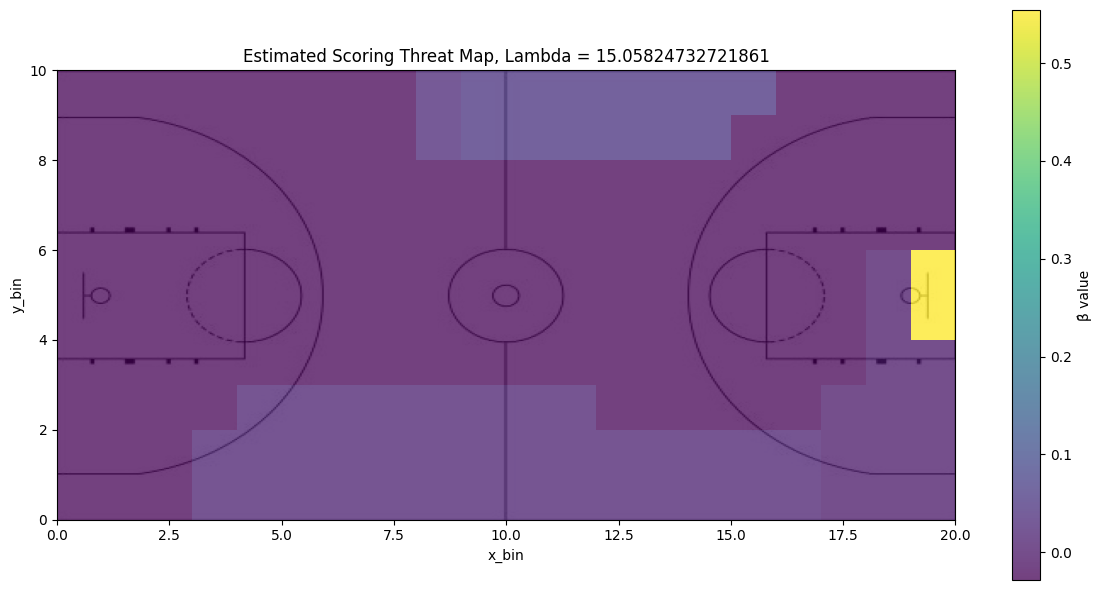

array([[-0.02854909, -0.02854909, -0.02854909, -0.02854909, -0.02854909,
        -0.02854907, -0.02854906, -0.02854906, -0.02854906, -0.02854906],
       [-0.02854909, -0.02854909, -0.02854909, -0.02854909, -0.02854909,
        -0.02854907, -0.02854906, -0.02854906, -0.02854906, -0.02854906],
       [-0.02854909, -0.02854909, -0.02854909, -0.02854909, -0.02854909,
        -0.02854909, -0.02854906, -0.02854906, -0.02854906, -0.02854906],
       [ 0.01498731,  0.01498731, -0.02854909, -0.02854909, -0.02854909,
        -0.02854909, -0.02854906, -0.02854906, -0.02854906, -0.02854906],
       [ 0.01498731,  0.01498731,  0.01498731, -0.02854909, -0.02854909,
        -0.02854909, -0.02854906, -0.02854906, -0.02854906, -0.02854906],
       [ 0.01498731,  0.01498731,  0.01498731, -0.0285491 , -0.0285491 ,
        -0.02854909, -0.02854906, -0.02854906, -0.02854906, -0.02854906],
       [ 0.01498731,  0.01498731,  0.01498731, -0.0285491 , -0.0285491 ,
        -0.02854909, -0.02854906, -0.02854906

In [4]:
tv_logistic_regression_heatmap(df, lambda_qut_val, plot=True)

## Bootstrapping Multiple Datasets for Comparison

For hypothesis testing, we need to create a distribution of the null and our actual $\lambda_{max}$. To do this, we follow the exact same steps covered above but we extend it to multiple bootstrapped datasets. The method has also been extended for customization, allowing you to input other datasets of that follow a similar structure and generate any amount of bootstraps with the option to fine tune how much sampling you would like to do. Reproducibilty is also built in.

Below cells contain functions for flipping and binning sectors, generating a $\lambda_{max}$ distribution visualization and some other useful statistics such a p-value for $\lambda_{max}$ and $\lambda_{QUT}$, confidence intervals and a threat propensity map similar to the one above.

In [5]:
# Flipping coordinates for unidirectional attack towards the right side basket

df_original = pd.read_csv("Data/analysis_ready_half_court_filtered.csv")

mask = df_original["period"] > 2
df_original.loc[mask, "x_bin"] = 20 - 1 - df_original.loc[mask, "x_bin"]
df_original.loc[mask, "y_bin"] = 10 - 1 - df_original.loc[mask, "y_bin"]

df_original['x_bin'] = np.clip(df_original['x_bin'], 0, 20 - 1)
df_original['y_bin'] = np.clip(df_original['y_bin'], 0, 10 - 1)

X, y, D_TV = grid(df_original)

In [6]:
# Function to compute lambda_max for each bootstrapped dataset

def compute_lambda_max_from_bootstraps(boot_datasets, D_TV, solve_lambda_func, project_grad_h=True):
    lambda_max_list = []

    for df_b in tqdm.tqdm(boot_datasets, desc="Computing λ_max for bootstraps"):
        # Build X, y from each bootstrapped dataset
        possessions = df_b['possession_number'].unique()
        grid_width, grid_height = 20, 10
        num_bins = grid_width * grid_height

        X = lil_matrix((len(possessions), num_bins), dtype=np.float32)
        y = np.array([group['scored'].iloc[0] for _, group in df_b.groupby('possession_number')], dtype=np.int8)
        possession_to_index = {p: i for i, p in enumerate(possessions)}
        bin_to_index = {(x, y): x * grid_height + y for x in range(grid_width) for y in range(grid_height)}

        for pid, group in df_b.groupby('possession_number'):
            i = possession_to_index[pid]
            visited_bins = set(zip(group['x_bin'], group['y_bin']))
            for xb, yb in visited_bins:
                if (xb, yb) in bin_to_index:
                    X[i, bin_to_index[(xb, yb)]] = 1

        try:
            _, lambda_max_b = solve_lambda_func(y, X, D_TV, project_grad_h=project_grad_h)
            if np.isfinite(lambda_max_b):
                lambda_max_list.append(lambda_max_b)
        except:
            continue

    return np.array(lambda_max_list)

In [7]:
# helper function to visualize distributions of observed lambda_max and the null

def summarize_lambda_max_analysis(
    lambda_max_obs,
    lambda_max_null,
    lambda_max_bootstrap,
    plot=True
):
    """
    Summarize the λ_max statistical test including CI, p-value, and QUT.

    Parameters:
    - lambda_max_obs (float): Observed λ_max from real or bootstrapped data
    - lambda_max_null (array-like): λ_max values simulated under the null
    - lambda_max_bootstrap (array-like): λ_max values from bootstrapped real data
    - plot (bool): Whether to plot the distributions

    Returns:
    - dict with keys: 'lambda_qut', 'lambda_max_obs', 'ci', 'p_value'
    """

    lambda_max_null = np.asarray(lambda_max_null)
    lambda_max_bootstrap = np.asarray(lambda_max_bootstrap)

    lambda_qut = np.percentile(lambda_max_null, 95)
    ci_lower, ci_upper = np.quantile(lambda_max_bootstrap, [0.025, 0.975])
    p_val = np.mean(lambda_max_null >= lambda_max_obs)

    # print(f"λ_qut (95th percentile null): {lambda_qut:.4f}")
    # print(f"λ_max (observed): {lambda_max_obs:.4f}")
    print(f"95% CI for λ_max (bootstrap): [{ci_lower:.4f}, {ci_upper:.4f}]")
    print(f"Empirical p-value (λ_max > λ_qut): {p_val:.4f}")

    if plot:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 6))
        plt.hist(lambda_max_null, bins=50, alpha=0.5, label="λ_max (null)", color="gray")
        plt.hist(lambda_max_bootstrap, bins=50, alpha=0.5, label="λ_max (bootstrap)", color="skyblue")
        plt.axvline(lambda_qut, color="black", linestyle="--", label="λ_qut (95%)")
        plt.axvline(lambda_max_obs, color="red", linestyle="--", label="λ_max (observed)")
        plt.xlabel("λ_max")
        plt.ylabel("Frequency")
        plt.title("λ_max: Bootstrap vs. Null Distribution")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        "lambda_qut": lambda_qut,
        "lambda_max_obs": lambda_max_obs,
        "ci": (ci_lower, ci_upper),
        "p_value": p_val
    }

Computing λ_max for bootstraps: 100%|██████████| 500/500 [00:57<00:00,  8.70it/s]


95% CI for λ_max (bootstrap): [31.1012, 45.2731]
Empirical p-value (λ_max > λ_qut): 0.0000


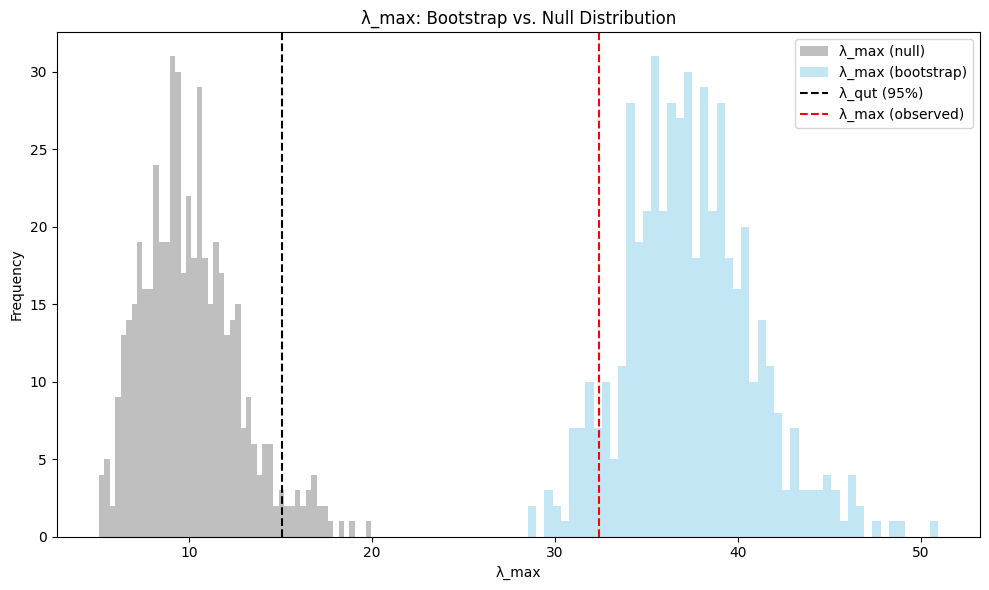

In [8]:
# Step 1: Generate bootstrapped datasets
boot_datasets = generate_bootstrapped_datasets(
    df_original,
    n_bootstraps=500,
    n_possessions_per_bootstrap=1000,
    samples_per_possession=100,
    min_samples_required=100,
    seed=42
)

# Step 2: Compute λ_max per bootstrap
lambda_max_bootstrap = compute_lambda_max_from_bootstraps(
    boot_datasets,
    D_TV,
    solve_lambda_func=solve_infinity_norm,
    project_grad_h=True
)

# Step 3: Compare to null distribution
summary = summarize_lambda_max_analysis(
    lambda_max_obs=lambda_max,
    lambda_max_null=lambdas_null,
    lambda_max_bootstrap=lambda_max_bootstrap,
    plot=True
)

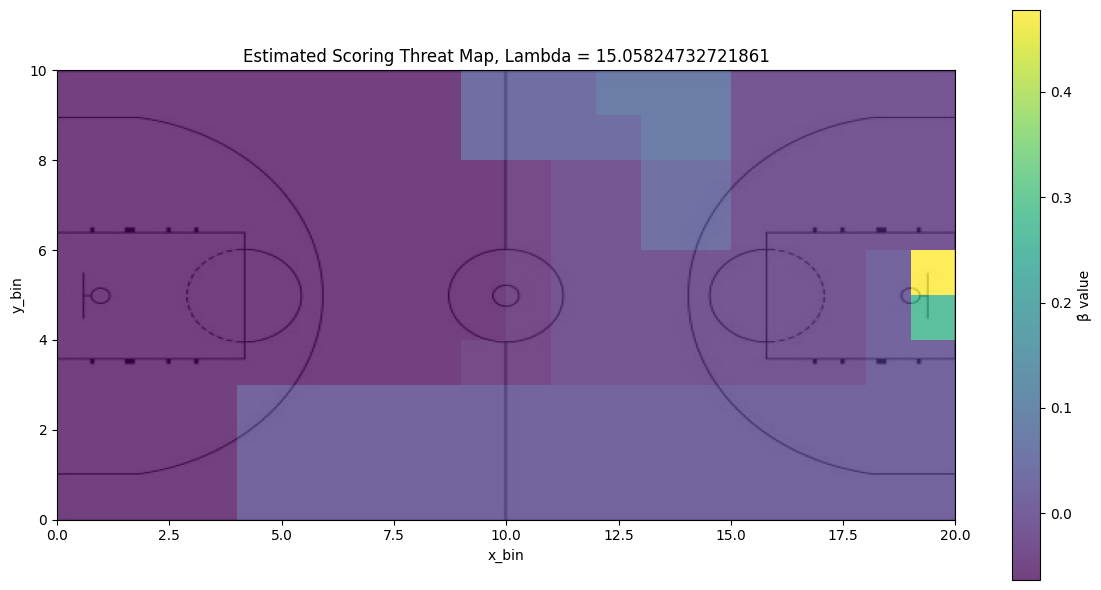

array([[-0.06323888, -0.06323888, -0.06323888, -0.06323888, -0.06323888,
        -0.06323888, -0.06323888, -0.06323888, -0.06323888, -0.06323888],
       [-0.06323888, -0.06323888, -0.06323888, -0.06323888, -0.06323888,
        -0.06323888, -0.06323888, -0.06323888, -0.06323888, -0.06323888],
       [-0.06323888, -0.06323888, -0.06323888, -0.06323888, -0.06323888,
        -0.06323888, -0.06323888, -0.06323888, -0.06323888, -0.06323888],
       [-0.06323888, -0.06323888, -0.06323888, -0.06323888, -0.06323888,
        -0.06323888, -0.06323888, -0.06323888, -0.06323888, -0.06323888],
       [ 0.01343221,  0.01343221,  0.01343221, -0.06323888, -0.06323888,
        -0.06323888, -0.06323888, -0.06323888, -0.06323888, -0.06323888],
       [ 0.01343221,  0.01343221,  0.01343221, -0.06323888, -0.06323888,
        -0.06323888, -0.06323888, -0.06323888, -0.06323888, -0.06323888],
       [ 0.01343221,  0.01343221,  0.01343221, -0.06323888, -0.06323888,
        -0.06323888, -0.06323888, -0.06323888

In [9]:
tv_logistic_regression_heatmap(boot_datasets[0], lambda_qut_val, plot = True)

## Pointwise Measurements for the QUT Generated $\lambda$

Using bootstrapped datsets, we can now do pointwise measurements for each sector of the court. We created three plots; a conservative measurement, realistic measurement and an optimistic measurement using the a 95% confidence interval, or an $\alpha$ of .05. This value can be adjusted for the user's needs. Alongside the aforementioned plots, we also constructed the mean value and standard deviation for each sector of the court.

In [10]:
# function for pointwise measurements (CI)

def bootstrap_percentile_maps_fixed_lambda(
    boot_datasets,             # list of bootstrapped DataFrames
    lambda_tv,                 # fixed λ (e.g., lambda_qut or lambda_max)
    grid_width, grid_height,   # grid shape
    court_image_path="court.jpg",
    alpha=0.05,
    show_progress=True
):
    """
    Calls tv_logistic_regression_heatmap on each bootstrap with fixed λ.
    Collects *logit* maps and returns percentile summaries on the logit scale.
    """
    B = len(boot_datasets)
    maps = None
    rng = np.random.default_rng(0)

    it = trange(B, desc=f"Bootstraps @ generated λ={lambda_tv:.4g}") if show_progress else range(B)
    for b in it:
        df_b = boot_datasets[b]

        out = tv_logistic_regression_heatmap(
            df_b,
            lambda_tv=lambda_tv,
            grid_width=grid_width,
            grid_height=grid_height,
            court_image_path=court_image_path,
            plot=False  # no plotting in loop
        )

        # Your function may return either logits or (logits, prob_map).
        beta_logit = out[0] if isinstance(out, tuple) else out  # ensure we keep logits
        if maps is None:
            maps = np.empty((B, grid_width, grid_height), dtype=np.float32)
        maps[b] = beta_logit

    # Pointwise percentile summaries on the logit scale
    q_lo, q_hi = alpha/2, 1 - alpha/2
    logit_lo  = np.quantile(maps, q_lo, axis=0)
    logit_med = np.median(maps, axis=0)
    logit_hi  = np.quantile(maps, q_hi, axis=0)

    return logit_med, logit_lo, logit_hi, maps

def plot_three_maps(logit_lo, logit_med, logit_hi, court_image_path, vlim=None):
    # Suggest a symmetric vlim if not provided, using robust percentiles
    if vlim is None:
        v = np.percentile(np.abs(np.stack([logit_lo, logit_med, logit_hi])), 95)
        vlim = (-float(v), float(v))

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    img = mpimg.imread(court_image_path)

    for ax, data, title in zip(
        axes,
        [logit_lo, logit_med, logit_hi],
        ["Conservative (Lower, logit)", "Realistic (Median, logit)", "Optimistic (Upper, logit)"]
    ):
        ax.imshow(img, extent=[0, data.shape[0], 0, data.shape[1]], aspect='auto')
        im = ax.imshow(
            data.T, origin="lower",
            extent=[0, data.shape[0], 0, data.shape[1]],
            cmap="coolwarm", alpha=0.75, vmin=vlim[0], vmax=vlim[1]
        )
        ax.set_xlabel("x_bin"); ax.set_ylabel("y_bin"); ax.set_title(title)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Logit (β̂)")

    plt.tight_layout(); plt.show()

Bootstraps @ generated λ=15.06: 100%|██████████| 500/500 [03:09<00:00,  2.64it/s]


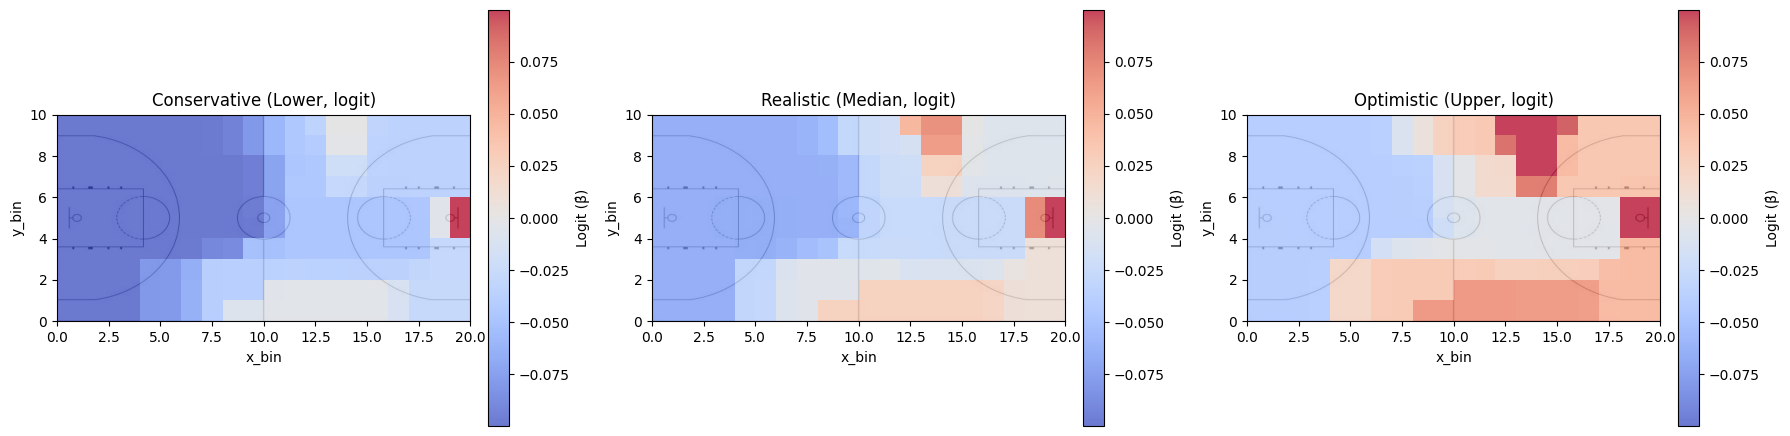

In [11]:
theta_hat, theta_lo, theta_hi, maps = bootstrap_percentile_maps_fixed_lambda(
    boot_datasets=boot_datasets,
    lambda_tv = lambda_qut_val,   #QUT or lambda_max
    grid_width=20, grid_height=10,
    court_image_path="court.jpg",
    alpha=0.05
)

# plot (optional)
plot_three_maps(theta_lo, theta_hat, theta_hi, "court.jpg")

In [12]:
# functions for pointwise measurements (mean, std)

def generate_beta_samples_from_bootstraps(boot_datasets, lambda_tv=1.0):
    beta_list = []

    for df_b in tqdm.tqdm(boot_datasets, desc="Solving TV-Logistic"):
        try:
            beta_b = solve_tv_logistic_regression(df_b, lambda_tv=lambda_tv)
            beta_list.append(beta_b)
        except RuntimeError as e:
            print("Skipped due to optimization failure:", e)
            continue

    return np.stack(beta_list)

def compute_beta_summary_stats(beta_samples):
    """
    Compute mean and std dev per cell from bootstrapped beta samples.
    
    Parameters:
        beta_samples (np.ndarray): shape (B, grid_width, grid_height)
        
    Returns:
        beta_mean, beta_std (both np.ndarray): shape (grid_width, grid_height)
    """
    beta_mean = np.mean(beta_samples, axis=0)
    beta_std = np.std(beta_samples, axis=0)
    return beta_mean, beta_std

def plot_beta_mean_std(beta_mean, beta_std, court_image_path=None):
    """
    Visualize mean and standard deviation of beta values across the court grid.
    """
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    titles = ["Mean of β (Bootstrapped)", "Standard Deviation of β"]
    matrices = [beta_mean, beta_std]
    cmaps = ["viridis", "plasma"]

    for ax, data, title, cmap in zip(axes, matrices, titles, cmaps):
        if court_image_path:
            from PIL import Image
            court_img = Image.open(court_image_path)
            ax.imshow(court_img, extent=[0, 20, 0, 10], aspect='auto')

        im = ax.imshow(data.T, origin="lower", extent=[0, 20, 0, 10],
                       cmap=cmap, alpha=0.7)
        ax.set_title(title)
        ax.set_xlabel("Court X")
        ax.set_ylabel("Court Y")
        plt.colorbar(im, ax=ax, shrink=0.8)

    plt.tight_layout()
    plt.show()


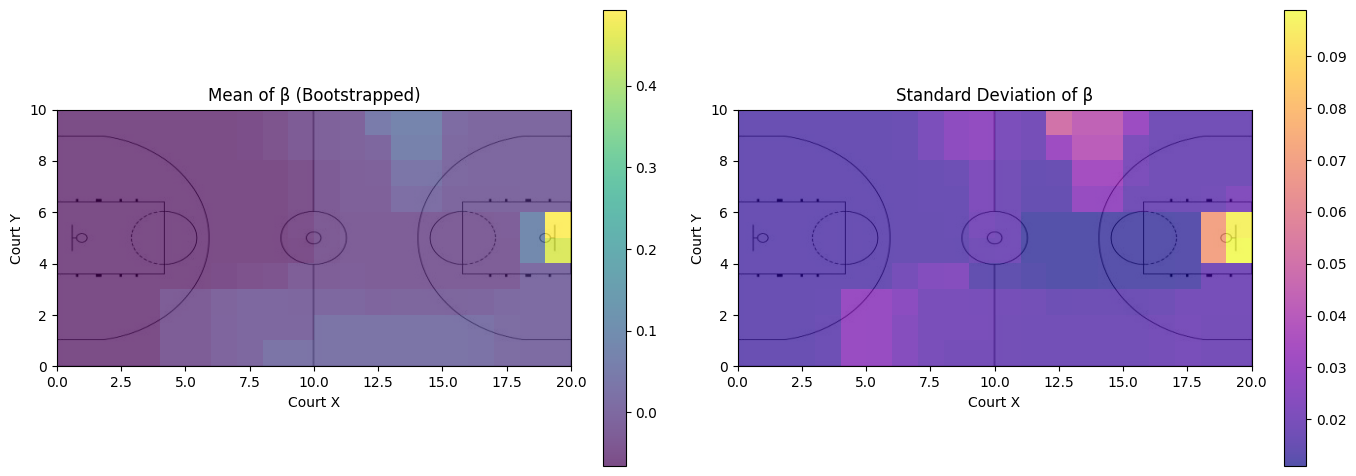

In [13]:
beta_samples = maps
beta_mean, beta_std = compute_beta_summary_stats(beta_samples)
plot_beta_mean_std(beta_mean, beta_std, court_image_path="court.jpg")

## Bootstrapping and QUT For Each Quarter

To enhance our analysis, we will also apply the QUT method and bootstrapping to individual quarters of the game. As above, we will be generating the QUT for each quarter with the exact same bootstrap process of 1000 possesions and 100 movements from each. Using the generated QUT, we will then use that for our $\lambda$ value to generate heatmaps of the conservative, realistic and optimistic scoring threats.

Because we are now iterating through each quarter, the lambda QUT value will be dynamically generated for ease of use and to properly implement the QUT method.

In [14]:
def analyze_tv_logistic_per_period(
    df_original,
    n_bootstraps=250,
    n_possessions=1000,
    samples_per_possession=100,
    min_samples_required=100,
    grid_width=20,
    grid_height=10,
    # null + plotting controls
    mc_null=250,                     # number of Monte Carlo null simulations per period
    alpha=0.05,                       # confidence level for pointwise maps
    court_image_path="court.jpg",
    show_progress=True,
    plot_beta_summary=True,
    plot_pointwise_maps=True,
    plot_lambda_distributions=True,
    seed_base=42
):
    """
    For each period:
      • Builds bootstrap datasets
      • Computes λ_qut for that period via Monte Carlo null simulations
      • Computes β summaries (mean/std) at λ = λ_qut(period)
      • Computes λ statistics (λ_max_obs, bootstrap CI, p-value) using summarize_lambda_max_analysis()
      • Computes pointwise percentile maps (logit) at λ = λ_qut(period)

    Notes:
      - λ_qut is computed separately for each period using the same D_TV structure.
      - The p-value returned by summarize_lambda_max_analysis is computed as
        mean(lambda_max_null >= lambda_max_obs).
    """
    rng = np.random.default_rng(seed_base)
    period_results = {}
    periods = sorted(df_original['period'].unique())

    for period in periods:
        print(f"\n=== Processing Period {period} ===")

        df_period = df_original[df_original['period'] == period]

        # ---------- Step 0: Bootstrap datasets ----------
        boot_datasets = generate_bootstrapped_datasets(
            df_period,
            n_bootstraps=n_bootstraps,
            n_possessions_per_bootstrap=n_possessions,
            samples_per_possession=samples_per_possession,
            min_samples_required=min_samples_required,
            seed=seed_base + period
        )

        # ---------- Step 1: Compute λ_qut for this period ----------
        df_boot = boot_datasets[0]
        X, y, D_TV = grid(df_boot)

        lambda_qut_val, lambda_max_obs, lambdas_null = lambda_qut(X, y, D_TV, MC=mc_null)
        print(f"λ_qut (period {period}): {lambda_qut_val:.4f}")

        # ---------- Step 2: Bootstrap λ_max and summarize ----------
        lambda_max_bootstrap_rest = compute_lambda_max_from_bootstraps(
            boot_datasets[1:],
            D_TV,
            solve_lambda_func=solve_infinity_norm
        )
        lambda_max_bootstrap = np.concatenate([
            np.asarray([lambda_max_obs], dtype=float),
            np.asarray(lambda_max_bootstrap_rest, dtype=float)
        ])

        stats = summarize_lambda_max_analysis(
            lambda_max_obs=float(lambda_max_obs),
            lambda_max_null=np.asarray(lambdas_null, dtype=float),
            lambda_max_bootstrap=np.asarray(lambda_max_bootstrap, dtype=float),
            plot=plot_lambda_distributions
        )

        # ---------- Step 3: Pointwise percentile maps using λ_qut ----------
        logit_med, logit_lo, logit_hi, maps_all = bootstrap_percentile_maps_fixed_lambda(
            boot_datasets=boot_datasets,
            lambda_tv=lambda_qut_val,
            grid_width=grid_width,
            grid_height=grid_height,
            court_image_path=court_image_path,
            alpha=alpha,
            show_progress=show_progress
        )

        # ---------- Step 4: β summaries using the fitted pointwise maps ----------
        beta_samples = maps_all
        beta_mean, beta_std = compute_beta_summary_stats(beta_samples)
        if plot_beta_summary:
            plot_beta_mean_std(beta_mean, beta_std, court_image_path=court_image_path)

        if plot_pointwise_maps:
            print(f"Plotting pointwise percentile maps at λ = {lambda_qut_val:.4f}")
            plot_three_maps(logit_lo, logit_med, logit_hi, court_image_path=court_image_path)

        # ---------- Step 5: Pack results ----------
        period_results[period] = {
            # β summaries at λ_qut
            "beta_samples": beta_samples,
            "beta_mean": beta_mean,
            "beta_std": beta_std,

            # λ statistics
            "lambda_qut": lambda_qut_val,
            "lambda_max_obs": stats["lambda_max_obs"],
            "lambda_max_ci": stats["ci"],
            "p_value": stats["p_value"],

            # raw distributions
            "lambda_null": np.asarray(lambdas_null, dtype=float),
            "lambda_max_bootstrap": np.asarray(lambda_max_bootstrap, dtype=float),

            # Pointwise percentile maps
            "pointwise": {
                "lambda": float(lambda_qut_val),
                "alpha": float(alpha),
                "logit_lo": logit_lo,
                "logit_med": logit_med,
                "logit_hi": logit_hi,
                "maps": maps_all,   # shape: (B, grid_width, grid_height)
            }
        }

    return period_results



=== Processing Period 1 ===


Generating Bootstrapped Datasets: 100%|██████████| 250/250 [01:15<00:00,  3.30it/s]


Simulating null responses...
Accepted 100 / 250 simulations
Accepted 200 / 250 simulations
λ_qut (95th percentile null): 15.1013
λ_max (data): 49.4955
λ_qut (period 1): 15.1013


Computing λ_max for bootstraps: 100%|██████████| 249/249 [00:26<00:00,  9.24it/s]

95% CI for λ_max (bootstrap): [36.9792, 51.2019]
Empirical p-value (λ_max > λ_qut): 0.0000


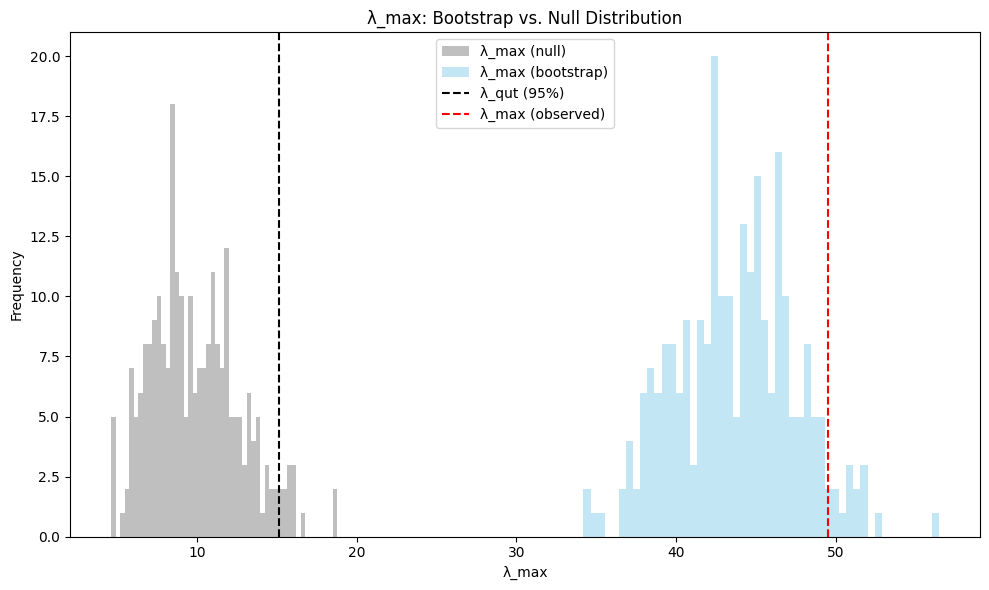

Bootstraps @ generated λ=15.1: 100%|██████████| 250/250 [01:34<00:00,  2.66it/s]


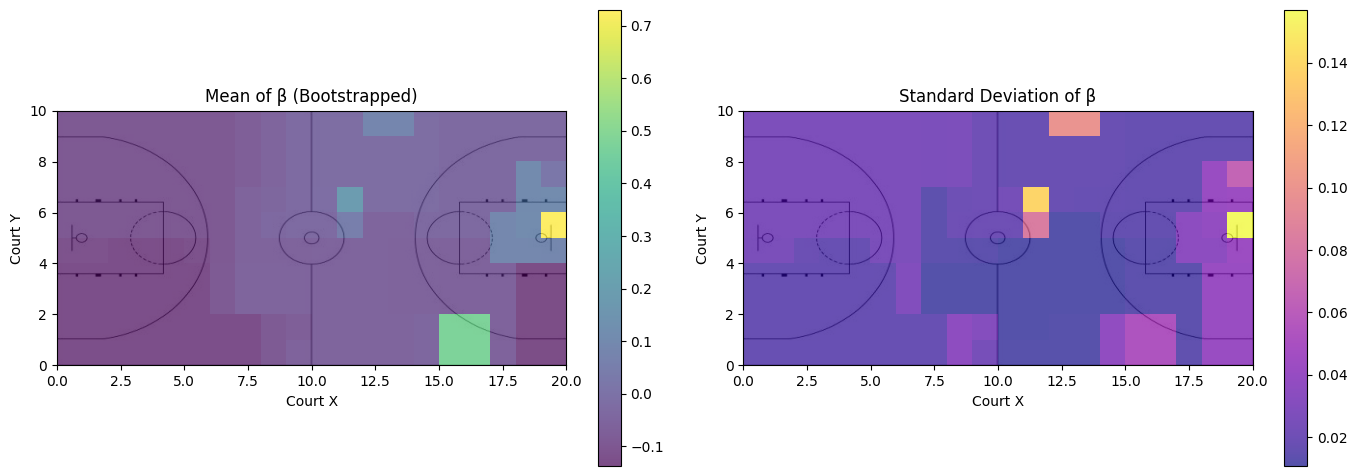

Plotting pointwise percentile maps at λ = 15.1013


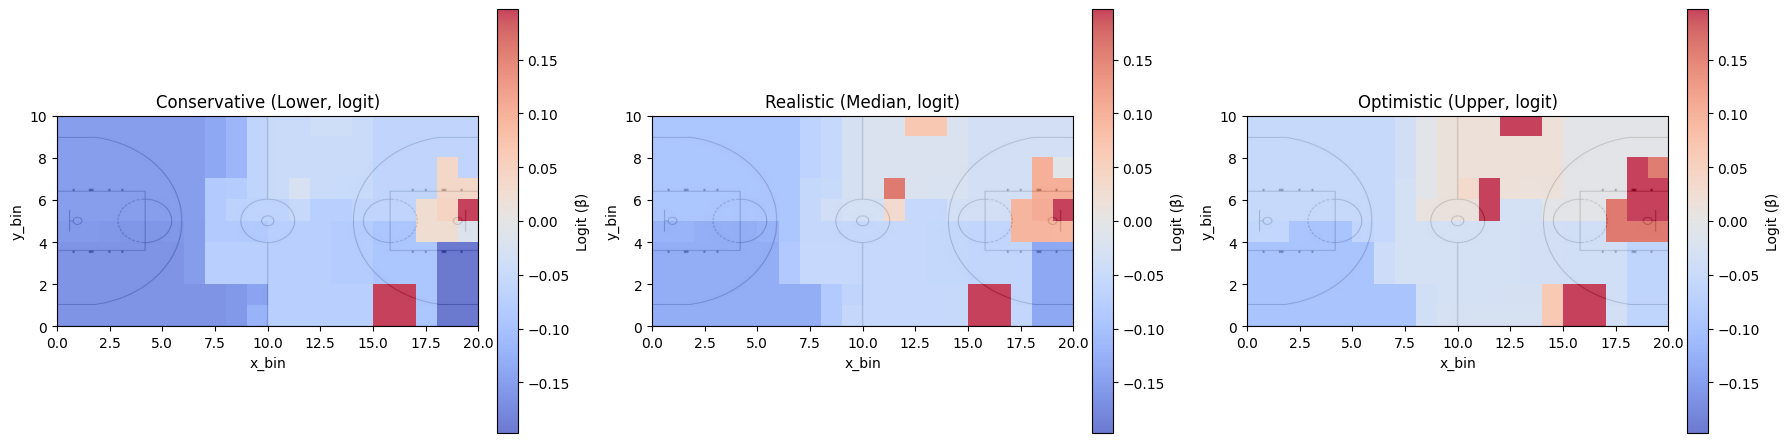


=== Processing Period 2 ===


Generating Bootstrapped Datasets: 100%|██████████| 250/250 [01:16<00:00,  3.26it/s]


Simulating null responses...
Accepted 100 / 250 simulations
Accepted 200 / 250 simulations
λ_qut (95th percentile null): 14.7665
λ_max (data): 52.3305
λ_qut (period 2): 14.7665


Computing λ_max for bootstraps: 100%|██████████| 249/249 [00:28<00:00,  8.89it/s]


95% CI for λ_max (bootstrap): [42.7942, 57.2342]
Empirical p-value (λ_max > λ_qut): 0.0000


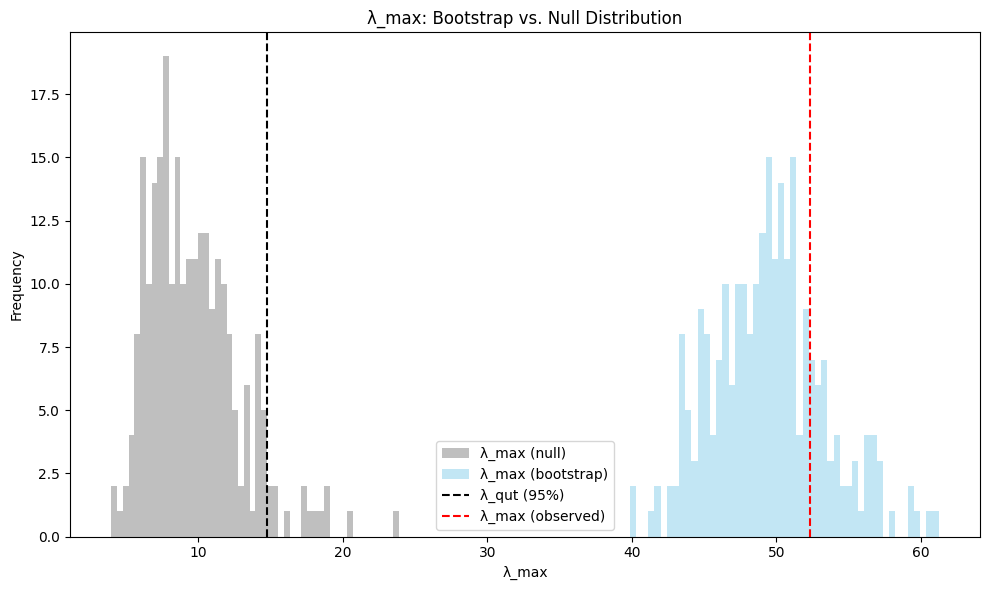

Bootstraps @ generated λ=14.77: 100%|██████████| 250/250 [01:32<00:00,  2.70it/s]


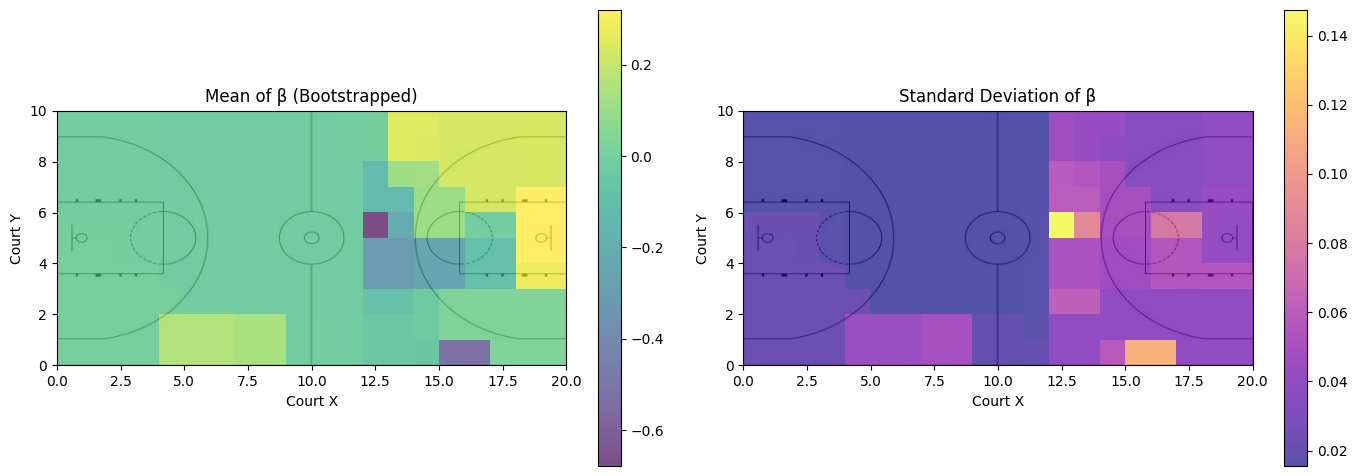

Plotting pointwise percentile maps at λ = 14.7665


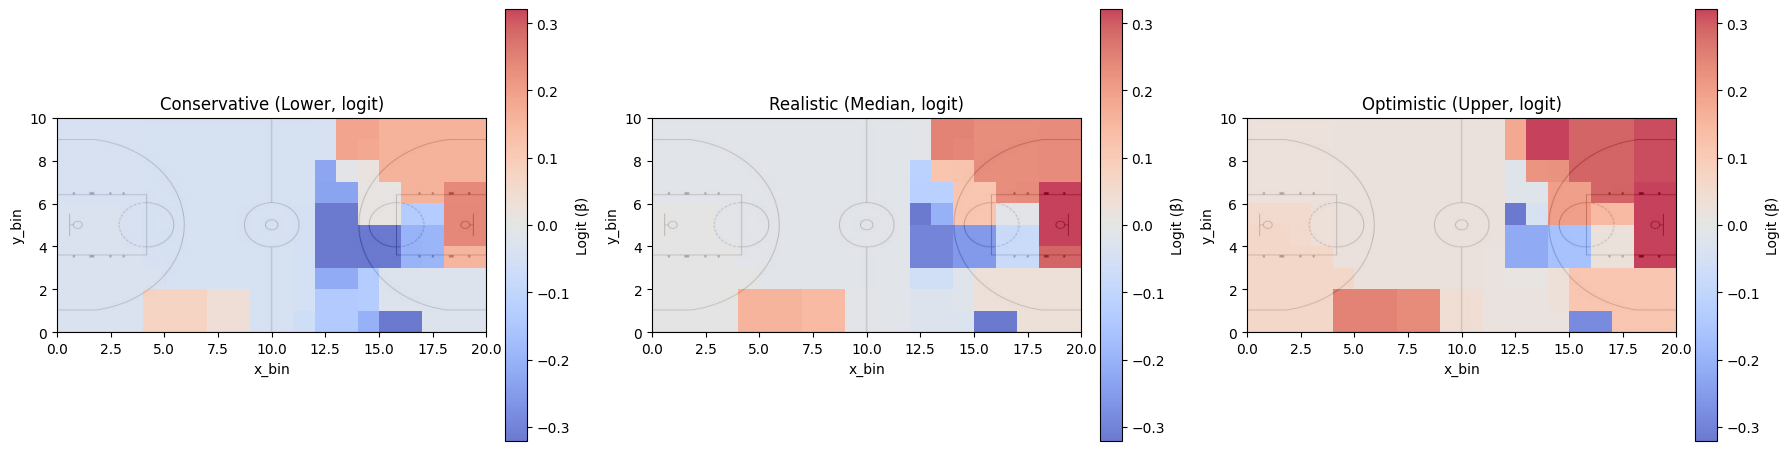


=== Processing Period 3 ===


Generating Bootstrapped Datasets: 100%|██████████| 250/250 [01:15<00:00,  3.32it/s]


Simulating null responses...
Accepted 100 / 250 simulations
Accepted 200 / 250 simulations
λ_qut (95th percentile null): 13.6764
λ_max (data): 82.1441
λ_qut (period 3): 13.6764


Computing λ_max for bootstraps: 100%|██████████| 249/249 [00:26<00:00,  9.34it/s]


95% CI for λ_max (bootstrap): [78.8876, 93.7553]
Empirical p-value (λ_max > λ_qut): 0.0000


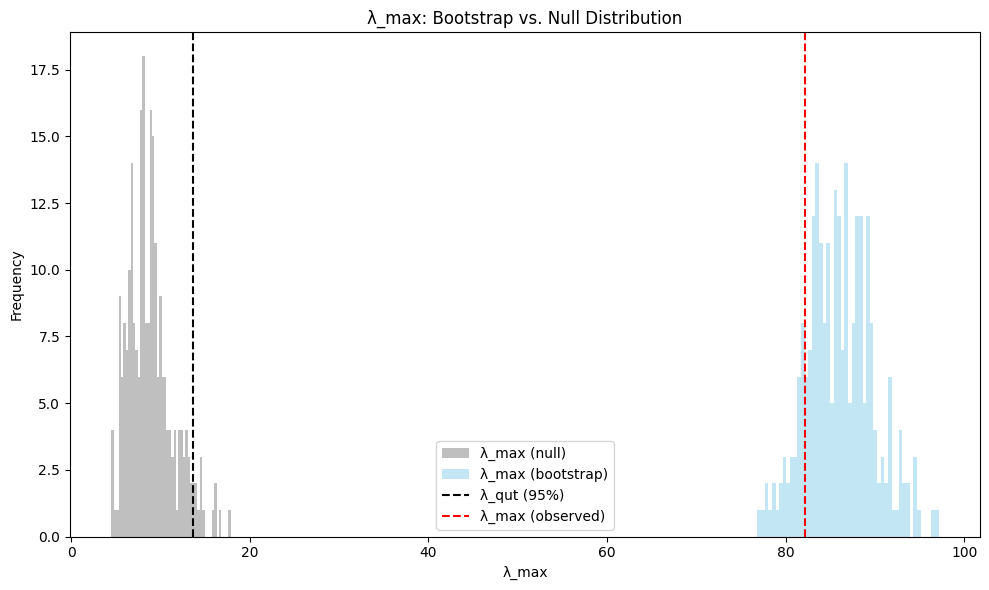

Bootstraps @ generated λ=13.68: 100%|██████████| 250/250 [01:31<00:00,  2.72it/s]


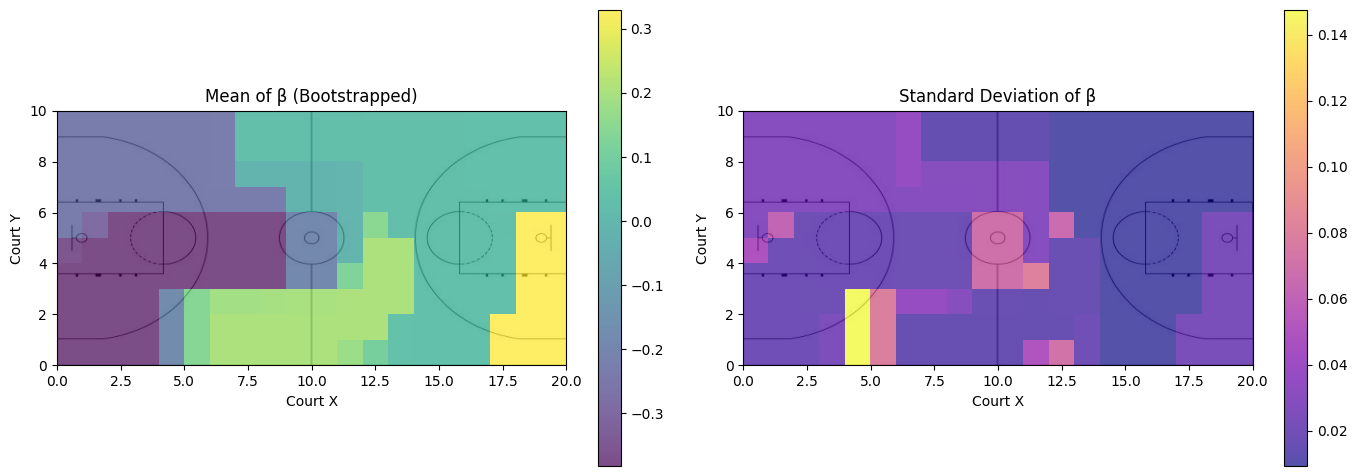

Plotting pointwise percentile maps at λ = 13.6764


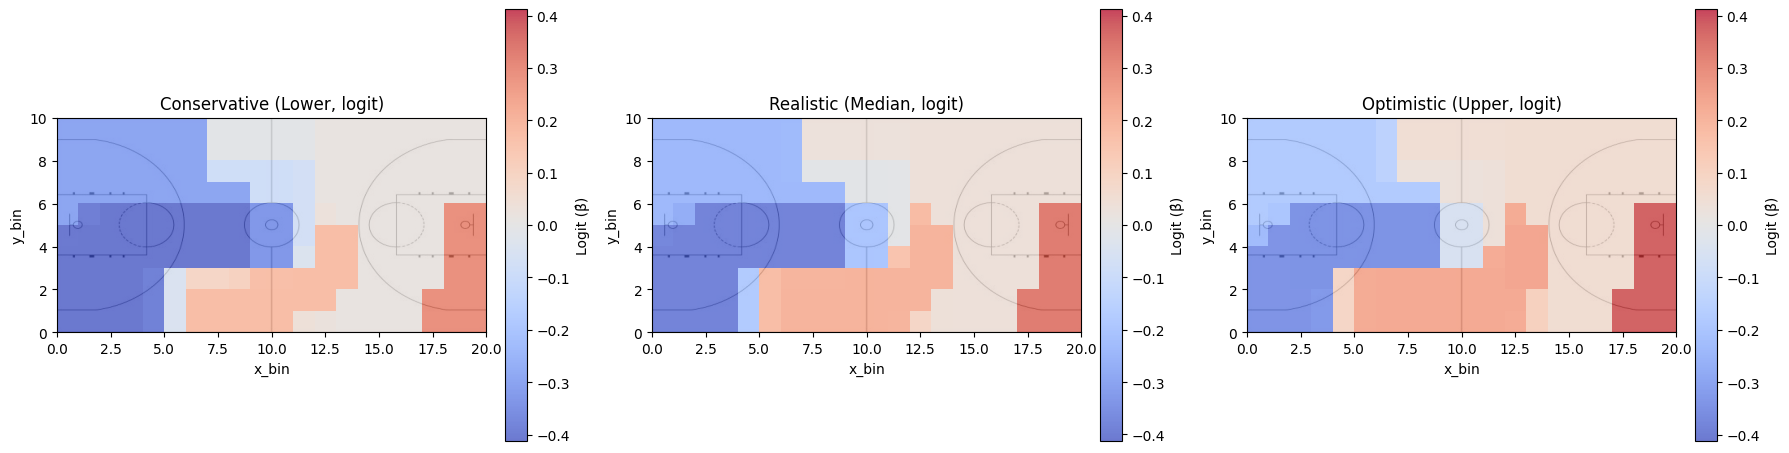


=== Processing Period 4 ===


Generating Bootstrapped Datasets: 100%|██████████| 250/250 [01:12<00:00,  3.43it/s]


Simulating null responses...
Accepted 100 / 250 simulations
Accepted 200 / 250 simulations
λ_qut (95th percentile null): 15.1393
λ_max (data): 77.3274
λ_qut (period 4): 15.1393


Computing λ_max for bootstraps: 100%|██████████| 249/249 [00:26<00:00,  9.32it/s]

95% CI for λ_max (bootstrap): [66.9277, 85.1178]
Empirical p-value (λ_max > λ_qut): 0.0000


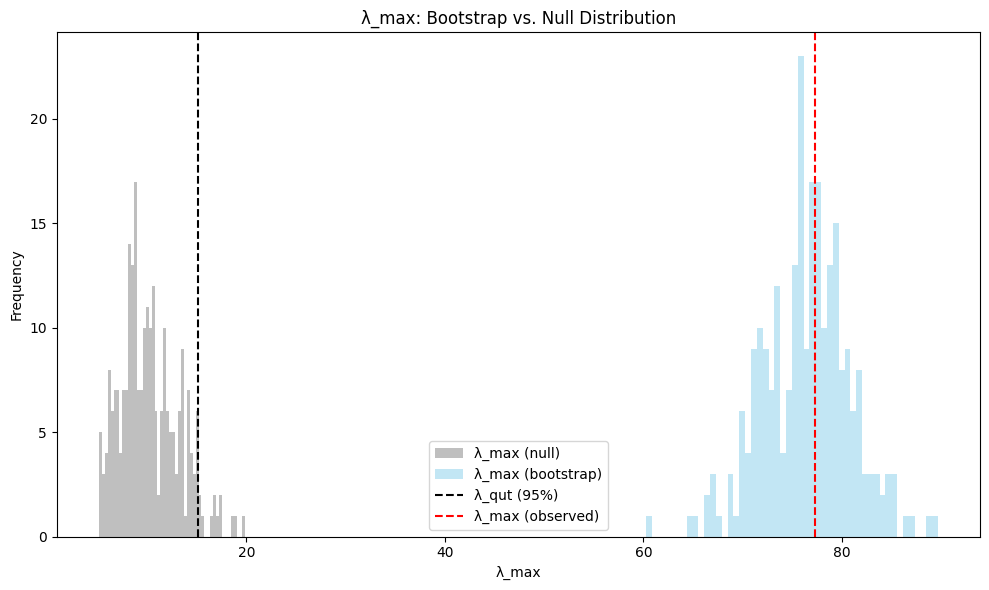

Bootstraps @ generated λ=15.14: 100%|██████████| 250/250 [01:30<00:00,  2.76it/s]


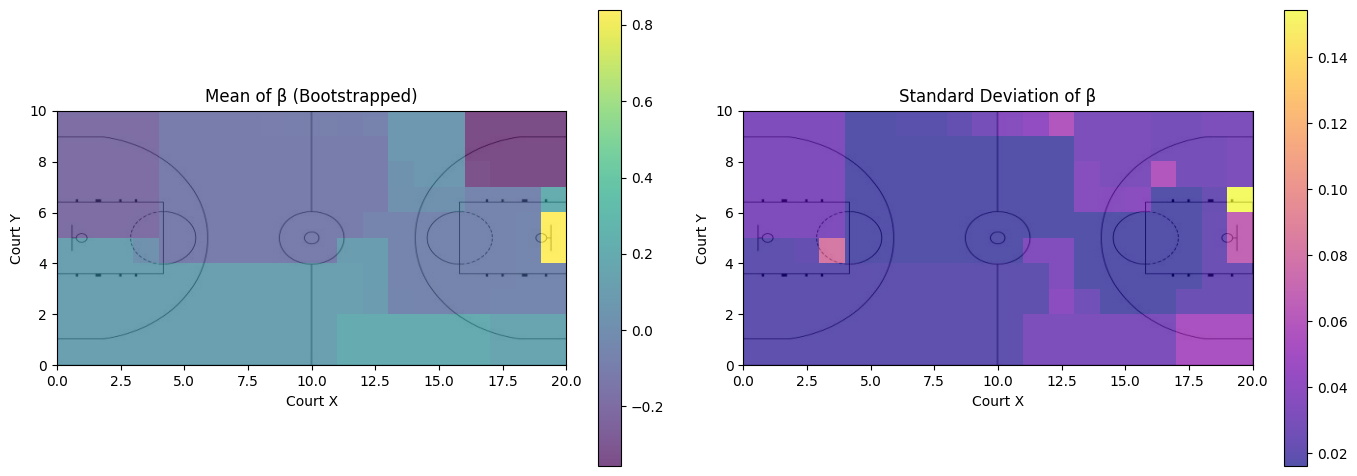

Plotting pointwise percentile maps at λ = 15.1393


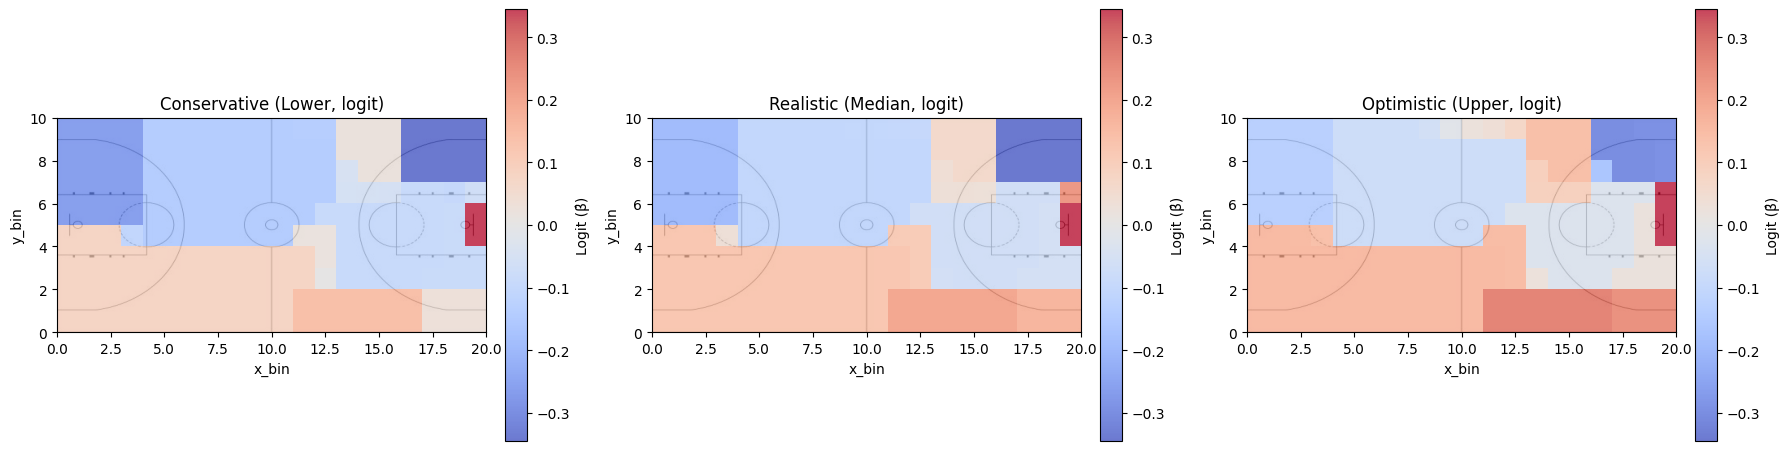

In [15]:
results = analyze_tv_logistic_per_period(df_original)

## Conclusion and Next Steps

We have succesfully implemented the QUT method in a controlled environment. We see that the $\lambda$ values generated for the entire game and on a per quarter basis are significantly different assuming that there is a signal to be captured. Furthermore, the pointwise statistics, heatmaps and distributions confirm this as well. There is also evidence of structure within the generated threat maps as well, indicating that the method was not only able to capture a signal, but it may be able to generate meaningful visuals in a live environment. Before we come to any conclusions on its practical applications, we must perform more testing.

The next steps we will take will likely be running more simulations but under the naive assumptions we generated using basic probability in the `NBA_Analysis.ipynb` file to see if we are are actually generating useful information. If we are generating new and insightful outputs, we can move towards running this on more possesions from other games to see how well the model performs with more live data. Lastly, we can also attempt running simulations by running the model on possessions in an iterative fashion for practical use in a live game.